In [1]:
using LowLevelFEM, Plots

In [2]:
#structured_rect_mesh()
openGeometry("bearings.geo")
#openPreProcessor()

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Reading 'bearings.geo'...
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 30%] Meshing curve 5 (Line)
Info    : [ 40%] Meshing curve 6 (Line)
Info    : [ 40%] Meshing curve 7 (Line)
Info    : [ 50%] Meshing curve 8 (Line)
Info    : [ 60%] Meshing curve 9 (Line)
Info    : [ 60%] Meshing curve 10 (Line)
Info    : [ 70%] Meshing curve 11 (Line)
Info    : [ 70%] Meshing curve 12 (Line)
Info    : [ 80%] Meshing curve 13 (Line)
Info    : [ 90%] Meshing curve 14 (Line)
Info    : [ 90%] Meshing curve 15 (Line)
Info    : [100%] Meshing curve 16 (Line)
Info    : Done meshing 1D (Wall 0.00584124s, CPU 0.002347s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 2 (Plane, Frontal-Delaunay)

In [3]:


mat1 = Material("rubber", μ=1, ν=0.49, c=1.8e9, ρ=1.1e-9, k=2e-4, α=2e-4)
mat2 = Material("steel")
Pu = Problem([mat1, mat2], type=:VectorField, dim=2, field=:u, rhs_field=:f)
PT = Problem([mat1, mat2], type=:ScalarField, dim=2, field=:T, rhs_field=:q)

Problem("bearings", :ScalarField, 2, 1, Material[Material("rubber", :Hooke, 2.98, 0.49, 48.99999999999996, 1.0, 49.66666666666662, 1.1e-9, 0.0002, 1.8e9, 0.0002, 1.0e-7, 0.1, 1.0), Material("steel", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 3771, LowLevelFEM.Geometry("", "", 0, 0, nothing, nothing, nothing, nothing), :T, :q)

In [4]:
E = mat1.E
ν = mat1.ν
k = mat1.k
α = mat1.α
κ = mat1.κ
ρ = mat1.ρ
c = mat1.c

E2 = mat2.E
ν2 = mat2.ν
k2 = mat2.k
α2 = mat2.α
κ2 = mat2.κ
ρ2 = mat2.ρ
c2 = mat2.c

#T0 = 293

μ = mat1.μ
tanδ = 0.07 # veszteségi tényező
freq = 1 # Hz
η = μ * tanδ / (2π * freq)
ϑ = 0.5

u00 = 2
v00 = 0.1
freq = 2
sample = 20
np = 1

dt = 1 / freq / sample
D1 = E / (1 + ν) / (1 - 2ν) * [1-ν ν 0; ν 1-ν 0; 0 0 (1-2ν)/2]
D2 = E2 / (1 + ν2) / (1 - 2ν2) * [1-ν2 ν2 0; ν2 1-ν2 0; 0 0 (1-2ν2)/2]

3×3 Matrix{Float64}:
 2.69231e5  1.15385e5      0.0
 1.15385e5  2.69231e5      0.0
 0.0        0.0        76923.1

In [5]:
Dv = η * [4 -2 0; -2 4 0; 0 0 3] / 3

3×3 Matrix{Float64}:
  0.0148545   -0.00742723  0.0
 -0.00742723   0.0148545   0.0
  0.0          0.0         0.0111408

In [6]:
Ku1 = ∫(SymGrad(Pu) ⋅ D1 ⋅ SymGrad(Pu), Ω="rubber")
Ku2 = ∫(SymGrad(Pu) ⋅ D2 ⋅ SymGrad(Pu), Ω="steel")
Ku = Ku1 + Ku2

sparse([1, 2, 33, 34, 543, 544, 6633, 6634, 1, 2  …  1265, 1266, 1623, 1624, 7359, 7360, 7535, 7536, 7541, 7542], [1, 1, 1, 1, 1, 1, 1, 1, 2, 2  …  7542, 7542, 7542, 7542, 7542, 7542, 7542, 7542, 7542, 7542], [21.583302491977033, 13.397459621556312, -18.533320996790728, 17.801270189221896, 6.466679003209288, -6.198729810778178, -9.516660498395595, -25.000000000000036, 13.397459621556312, 21.58330249197705  …  117364.70288880459, -244601.69085384568, 100757.42888594701, -70576.54164042612, -48701.97308243235, 10898.877876407372, -23583.942416019094, -272358.62515797105, -49682.370122453845, 702496.5195645385], 7542, 7542)

In [7]:
Kv = ∫(SymGrad(Pu) ⋅ Dv ⋅ SymGrad(Pu), Ω="rubber")

sparse([1, 2, 33, 34, 543, 544, 6633, 6634, 1, 2  …  1993, 1994, 3489, 3490, 3563, 3564, 4241, 4242, 6989, 6990], [1, 1, 1, 1, 1, 1, 1, 1, 2, 2  …  6990, 6990, 6990, 6990, 6990, 6990, 6990, 6990, 6990, 6990], [0.010789703507207874, 0.0009950602310342224, -0.003944519869002015, -0.00421114545432801, -0.002087712199596574, 0.005072892892699236, -0.004757471438609285, -0.0018568076694054506, 0.0009950602310342224, 0.010789703507207874  …  0.0020069419319663118, -0.01432770909020724, 0.002109816668647243, -0.014240935219003648, -0.001514587722167015, -0.012869108746803054, -0.001701889207393694, -0.010874793306302009, -0.0009002816710528464, 0.05231254636231595], 7542, 7542)

In [8]:
f = ∫(Pu ⋅ [0.0, 0], Γ="top")

nodal VectorField
[0.0; 0.0; … ; 0.0; 0.0;;]

In [9]:
KT1 = ∫(Grad(PT) ⋅ k ⋅ Grad(PT), Ω="rubber")
KT2 = ∫(Grad(PT) ⋅ k2 ⋅ Grad(PT), Ω="steel")
KT = KT1 + KT2

sparse([1, 17, 272, 3317, 2, 115, 116, 3323, 3, 144  …  723, 3767, 3769, 3770, 13, 633, 812, 3680, 3768, 3771], [1, 1, 1, 1, 2, 2, 2, 2, 3, 3  …  3770, 3770, 3770, 3770, 3771, 3771, 3771, 3771, 3771, 3771], [0.00016602540378443892, -4.641016151377484e-5, -4.641016151377498e-5, -7.320508075688908e-5, 0.00016571219810741734, -4.005211603633237e-5, -4.005211603633254e-5, -8.560796603475239e-5, 0.00016602540378443887, -4.641016151377413e-5  …  -47.08169790061172, -18.823057285283326, -39.21015225715962, 170.37674663976162, -32.73399161296665, -47.02396681390052, -34.63890060259658, -17.746951963974738, -38.30767854103381, 170.45148953447227], 3771, 3771)

In [10]:
CT1 = ∫(PT ⋅ (c * ρ) ⋅ PT, Ω="rubber")
CT2 = ∫(PT ⋅ (c2 * ρ2) ⋅ PT, Ω="steel")
CT = CT1 + CT2

sparse([1, 17, 272, 3317, 2, 115, 116, 3323, 3, 144  …  723, 3767, 3769, 3770, 13, 633, 812, 3680, 3768, 3771], [1, 1, 1, 1, 2, 2, 2, 2, 3, 3  …  3770, 3770, 3770, 3770, 3771, 3771, 3771, 3771, 3771, 3771], [0.24157676649772886, 0.06039419162443215, 0.06039419162443232, 0.12078838324886457, 0.23108599145994885, 0.057771497864987156, 0.057771497864987295, 0.11554299572997455, 0.24157676649772797, 0.06039419162443171  …  0.17270148946431157, 0.17296491065989864, 0.14073281112773878, 0.7898004179936621, 0.15905197802312102, 0.16909028046007443, 0.1389799208052606, 0.17363086764168217, 0.14326910226942785, 0.7840221491995658], 3771, 3771)

In [11]:
q = ∫(PT ⋅ 0)

nodal ScalarField
[0.0; 0.0; … ; 0.0; 0.0;;]

In [12]:
supp_bot = BoundaryCondition("bottom", problem=Pu, ux=0, uy=0)
supp_top = BoundaryCondition("top", problem=Pu, ux=u00, uy=(-v00))

BoundaryCondition("top", Problem("bearings", :VectorField, 2, 2, Material[Material("rubber", :Hooke, 2.98, 0.49, 48.99999999999996, 1.0, 49.66666666666662, 1.1e-9, 0.0002, 1.8e9, 0.0002, 1.0e-7, 0.1, 1.0), Material("steel", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 3771, LowLevelFEM.Geometry("", "", 0, 0, nothing, nothing, nothing, nothing), :u, :f), Dict{Symbol, Union{Function, Number, ScalarField}}(:uy => -0.1, :ux => 2))

In [13]:
u = solveField(Ku, f, support=[supp_bot, supp_top])
γxy = ∂y(u[1]) + ∂x(u[2])

elementwise ScalarField
[[0.033736510852813185; 0.033736510852813185; 0.033736510852813185;;], [0.028373963511973653; 0.028373963511973653; 0.028373963511973653;;], [0.006520409524037471; 0.006520409524037471; 0.006520409524037471;;], [0.007750214507208399; 0.007750214507208399; 0.007750214507208399;;], [0.03305797946043351; 0.03305797946043351; 0.03305797946043351;;], [0.02225124385367855; 0.02225124385367855; 0.02225124385367855;;], [0.030177408033873115; 0.030177408033873115; 0.030177408033873115;;], [0.024906520617355696; 0.024906520617355696; 0.024906520617355696;;], [0.009289948581258117; 0.009289948581258117; 0.009289948581258117;;], [0.01072400905790788; 0.01072400905790788; 0.01072400905790788;;]  …  [-2.605193364924041e-7; -2.605193364924041e-7; -2.605193364924041e-7;;], [-2.218540979884165e-7; -2.218540979884165e-7; -2.218540979884165e-7;;], [8.280402252341945e-7; 8.280402252341945e-7; 8.280402252341945e-7;;], [1.0511257296508258e-6; 1.0511257296508258e-6; 1.0511257296508258

In [14]:
showDoFResults(u, name="u")
showElementResults(γxy, name="γxy")

1

In [15]:
u0 = 0f
u1 = 0f
T0 = 0q

εx = ∂x(u0[1])
εy = ∂y(u0[2])
γxy = ∂y(u0[1]) + ∂x(u0[2])

ε0 = [εx, εy, γxy]

3-element Vector{ScalarField}:
 ScalarField([[0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;]  …  [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;], [0.0; 0.0; 0.0;;]], Matrix{Float64}(undef, 0, 0), [0.0], [829, 830, 831, 832, 833, 834, 835, 836, 837, 838  …  8099, 8100, 8101, 8102, 8103, 8104, 8105, 8106, 8107, 8108], 1, :scalar, Problem("bearings", :VectorField, 2, 2, Material[Material("rubber", :Hooke, 2.98, 0.49, 48.99999999999996, 1.0, 49.66666666666662, 1.1e-9, 0.0002, 1.8e9, 0.0002, 1.0e-7, 0.1, 1.0), Material("steel", :Hooke, 200000.0, 0.3, 115384.61538461536, 76923.07692307692, 166666.66666666663, 7.85e-9, 45.0, 4.2e8, 1.2e-5, 1.0e-7, 0.1, 1.0)], 1.0, 3771, LowLevelFEM.Geometry("", "", 0, 0, nothing, nothing, nothing, not

In [16]:
diss = nothing
T1 = nothing

uu = VectorField[]
γγ = ScalarField[]
dd = ScalarField[]
TT = ScalarField[]

nn = np * sample
for i in 1:nn
    supp_top = BoundaryCondition("top", problem=Pu, ux=u00 * sin(2π / sample * i), uy=(-v00))
    u1 = solveField(Ku + Kv / dt, Kv * u0 / dt + f, support=[supp_bot, supp_top])
    push!(uu, copy(u1))

    εx = ∂x(u1[1])
    εy = ∂y(u1[2])
    γxy = ∂y(u1[1]) + ∂x(u1[2])
    ε1 = [εx, εy, γxy]

    push!(γγ, γxy)

    dε = (ε1 - ε0) / dt
    diss = dε' * Dv * dε
    push!(dd, elementsToNodes(copy(diss)))

    q_diss = ∫(PT ⋅ diss)

    #T1 = (CT + dt * ϑ * KT) \ ((CT - dt * (1 - ϑ) * KT) * T0 + dt * q_diss)
    T1 = solveField(CT + dt * ϑ * KT, (CT - dt * (1 - ϑ) * KT) * T0 + dt * q_diss)
    push!(TT, copy(T1))

    u0 = copy(u1)
    ε0 = copy(ε1)
    T0 = copy(T1)
end

In [17]:
u2 = 0f
uu2 = VectorField[]

for i in 1:0
    u2 = solveField(Ku + Kv / dt, Kv * u0 / dt + 20 * f, support=[supp_u])
    u0 = copy(u2)
    push!(uu2, copy(u2))
end
#uu2 = mergeFields(uu2)

In [18]:
uu = mergeFields(uu)
γγ = mergeFields(γγ)
dd = mergeFields(dd)
TT = mergeFields(TT)

nodal ScalarField
[0.0001225672039056381 0.00033455815607121394 … 0.002334154460647696 0.002603771879519604; 0.0005185105841479032 0.0007378634680799543 … 0.002688359505636293 0.002951285702618797; … ; 2.0355667007538558e-5 5.7437717721354414e-5 … 0.00018920608827391336 0.0002094310521631119; 4.9281831652857615e-5 0.000124861140578476 … 0.0002251241275869942 0.00024575920961490493]

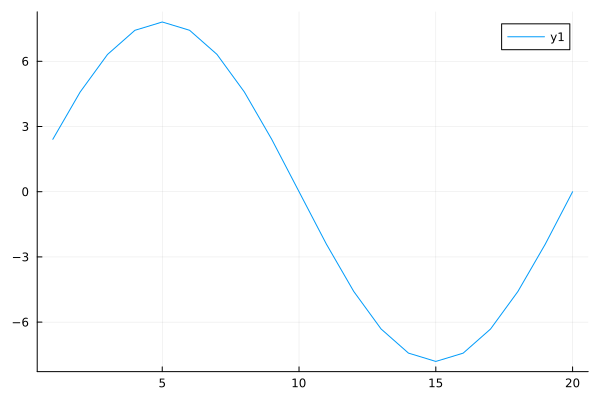

In [19]:
ττ = γγ * μ
F = zeros(np * sample)
for i in 1:(np*sample)
    F[i] = integrate(Pu, "top", ττ, step=i)
end
plot(F)

In [20]:
showDoFResults(uu, name="u")
showElementResults(γγ, name="γ")
showDoFResults(dd, name="diss")
showElementResults(TT, name="T")
#showDoFResults(εx, name="εx")

5

In [21]:
#showDoFResults(u1, name="u1")
#showDoFResults(uu2, name="uu2")
#showDoFResults(T1, name="T1")

In [22]:
openPostProcessor()

-------------------------------------------------------
Version       : 4.15.2-git
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 19700101
Build host    : amdci7.julia.csail.mit.edu
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blossom Cairo DIntegration Dlopen DomHex Eigen[contrib] Fltk GMP Gmm[contrib] Hxt Jpeg Kbipack LinuxJoystick MathEx[contrib] Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.8
OCC version   : 7.9.2
Packaged by   : root
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------


XOpenIM() failed
Fontconfig warning: using without calling FcInit()
